<a href="https://colab.research.google.com/github/vvelvadapu9/DemoAIProj/blob/Dev/NLP_Session.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
import pandas as pd
# Note : You can take any dataset
data=pd.read_csv("/content/cleaned_reviews.csv")

# Display first few rows
#print(data.head(10))

#data frame is 2 dimensional representation of data structure
#in pandas data is represted as data frame (usually in multiple rows/columns)

#data cleansing
data=data.dropna()
data.info()


#print(data.describe())

#checking duplicate and missing values
data.info()
print(data.isnull().sum())

#check for duplicates
print("Duplicates:", data.duplicated().sum())

#Remove duplicates
data=data.drop_duplicates()
print("Duplicates:", data.duplicated().sum())

# Add a new column for text length
data["review_length"] = data["cleaned_review"].apply(len)

# Display the first few rows with the new column
data.head()

#print(data["review_length"])
#print(data["review_length"]).describe()


<class 'pandas.core.frame.DataFrame'>
Index: 17337 entries, 0 to 17339
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sentiments             17337 non-null  object 
 1   cleaned_review         17337 non-null  object 
 2   cleaned_review_length  17337 non-null  int64  
 3   review_score           17337 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 677.2+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 17337 entries, 0 to 17339
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sentiments             17337 non-null  object 
 1   cleaned_review         17337 non-null  object 
 2   cleaned_review_length  17337 non-null  int64  
 3   review_score           17337 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 677.2+ KB
sentiments               0
cleaned_review 

AttributeError: 'NoneType' object has no attribute 'describe'

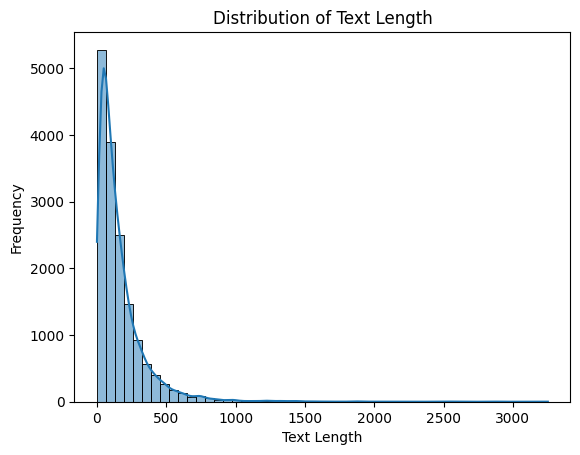

In [51]:
#Histogram of text lengths
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(data["review_length"], bins=50, kde=True)
plt.title("Distribution of Text Length")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()


In [55]:
from collections import Counter
import re
# Function to clean text and extract words
def get_words(text):
    text = text.lower() # Convert to lowercase
    text = re.sub(r"[^a-zA-Z\s]", "",text) #Remove special characters
    words = text.split()
    return words
# Get all words from the dataset
all_words = data["cleaned_review"].apply(get_words).sum()
# Count word frequencies
word_counts = Counter(all_words)
# Display the most common words
print(word_counts.most_common(20))


[('the', 25196), ('it', 21988), ('and', 16675), ('to', 12547), ('for', 9503), ('is', 9264), ('this', 8208), ('my', 6368), ('mouse', 5828), ('of', 5307), ('not', 4932), ('but', 4688), ('on', 4479), ('in', 4344), ('great', 4283), ('that', 4277), ('with', 4061), ('was', 3731), ('you', 3553), ('have', 3325)]


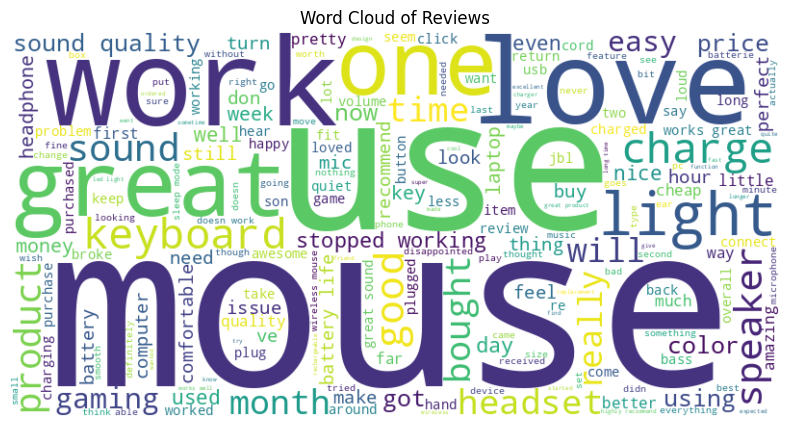

In [54]:
from wordcloud import WordCloud

wordcloud = WordCloud(width = 800, height = 400, background_color="white").generate(" ".join(all_words))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Reviews")
plt.show()